## **Prerequisites**


## **Summary**
This notebook presents a thorough machine learning project aimed at predicting chronic kidney disease (CKD) from patient data. It covers extensive data preprocessing, including imputation for missing values and encoding categorical features. Multiple classification models are explored. The workflow integrates feature selection with Recursive Feature Elimination (RFE) and dimensionality reduction via PCA to enhance model performance. Rigorous cross-validation and detailed metric evaluation (accuracy, precision, recall, F1-score) guide the identification of the best-performing models, illustrating a comprehensive approach to healthcare predictive modeling.

In [502]:
import warnings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

SEED = 42
DISPLAY_LABELS = ["no ckd", "ckd"]

warnings.filterwarnings("ignore")
np.random.seed(SEED)

## **Dataset**


### **Loading the Dataset**


In [503]:
data_dict = fetch_ucirepo(id=336)

In [504]:
type(data_dict)

ucimlrepo.dotdict.dotdict

### **Dataset Details**


In [505]:
data_dict.keys()

dict_keys(['data', 'metadata', 'variables'])

In [506]:
data_dict["metadata"]["has_missing_values"]

'yes'

In [507]:
data_dict["metadata"]["missing_values_symbol"]

'NaN'

In [508]:
vars = data_dict["variables"]

vars

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,year,yes
1,bp,Feature,Integer,None,blood pressure,mm/Hg,yes
2,sg,Feature,Categorical,None,specific gravity,None,yes
3,al,Feature,Categorical,None,albumin,None,yes
4,su,Feature,Categorical,None,sugar,None,yes
5,rbc,Feature,Binary,None,red blood cells,None,yes
6,pc,Feature,Binary,None,pus cell,None,yes
7,pcc,Feature,Binary,None,pus cell clumps,None,yes
8,ba,Feature,Binary,None,bacteria,None,yes
9,bgr,Feature,Integer,None,blood glucose random,mgs/dl,yes


In [509]:
var_types = {
    key: vars[vars["type"].isin(value)]["name"].to_list()
    for key, value in {
        "cat": ["Categorical"],
        "bin": ["Binary"],
        "int": ["Integer"],
        "cont": ["Continuous"],
    }.items()
}

var_types

{'cat': ['sg', 'al', 'su'],
 'bin': ['rbc',
  'pc',
  'pcc',
  'ba',
  'htn',
  'dm',
  'cad',
  'appet',
  'pe',
  'ane',
  'class'],
 'int': ['age', 'bp', 'bgr', 'bu', 'sod', 'pcv', 'wbcc'],
 'cont': ['sc', 'pot', 'hemo', 'rbcc']}

## **Dataframe**


In [510]:
df = pd.DataFrame(data_dict["data"]["original"])

df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


In [511]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    object 
 6   pc      335 non-null    object 
 7   pcc     396 non-null    object 
 8   ba      396 non-null    object 
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    object 
 19  dm      398 non-null    object 
 20  cad     398 non-null    object 
 21  appet   399 non-null    object 
 22  pe

## **Data Preprocessing**


### **Removing the Extra Whitespace**


In [512]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

### **Validating the Categorical and Binary Features**


In [513]:
for disc_col in var_types["cat"]:
    print(disc_col, df[disc_col].unique())

sg [1.02  1.01  1.005 1.015   nan 1.025]
al [ 1.  4.  2.  3.  0. nan  5.]
su [ 0.  3.  4.  1. nan  2.  5.]


In [514]:
for disc_col in var_types["bin"]:
    print(disc_col, df[disc_col].unique())

rbc [nan 'normal' 'abnormal']
pc ['normal' 'abnormal' nan]
pcc ['notpresent' 'present' nan]
ba ['notpresent' 'present' nan]
htn ['yes' 'no' nan]
dm ['yes' 'no' nan]
cad ['no' 'yes' nan]
appet ['good' 'poor' nan]
pe ['no' 'yes' nan]
ane ['no' 'yes' nan]
class ['ckd' 'notckd']


### **Validating the Numerical Features**


In [515]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
pot,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000


### **Checking for Duplicates**


In [516]:
df.duplicated().sum()

np.int64(0)

### **Imputing the Missing Values**


In [517]:
for col_group in ("cat", "bin"):
    df[var_types[col_group]] = df[var_types[col_group]].apply(
        lambda col: col.fillna(np.random.choice(col.mode()))
    )

df[var_types["int"]] = df[var_types["int"]].apply(
    lambda col: col.fillna(col.median())
)

df[var_types["cont"]] = df[var_types["cont"]].apply(
    lambda col: col.fillna(col.mean())
)

df.isna().sum()

age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
class    0
dtype: int64

### **Handling DTypes**


In [518]:
bin_vals = {
    0: {"normal", "notpresent", "no", "good", "notckd"},
    1: {"abnormal", "present", "yes", "poor", "ckd"},
}

df[var_types["bin"]] = (
    df[var_types["bin"]]
    .map(
        lambda val: {
            value: key for key, values in bin_vals.items() for value in values
        }.get(val, val)
    )
    .astype("int8")
)

df[var_types["int"]] = df[var_types["int"]].astype("int64")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     400 non-null    int64  
 1   bp      400 non-null    int64  
 2   sg      400 non-null    float64
 3   al      400 non-null    float64
 4   su      400 non-null    float64
 5   rbc     400 non-null    int8   
 6   pc      400 non-null    int8   
 7   pcc     400 non-null    int8   
 8   ba      400 non-null    int8   
 9   bgr     400 non-null    int64  
 10  bu      400 non-null    int64  
 11  sc      400 non-null    float64
 12  sod     400 non-null    int64  
 13  pot     400 non-null    float64
 14  hemo    400 non-null    float64
 15  pcv     400 non-null    int64  
 16  wbcc    400 non-null    int64  
 17  rbcc    400 non-null    float64
 18  htn     400 non-null    int8   
 19  dm      400 non-null    int8   
 20  cad     400 non-null    int8   
 21  appet   400 non-null    int8   
 22  pe

### **Correlation Analysis**


In [519]:
corr = df.corr()

corr["class"].abs().sort_values(ascending=False)[1:13]

hemo     0.729628
pcv      0.673129
sg       0.659504
rbcc     0.590913
htn      0.590438
dm       0.559060
al       0.531562
appet    0.393341
bgr      0.379321
pc       0.375154
pe       0.375154
bu       0.369344
Name: class, dtype: float64

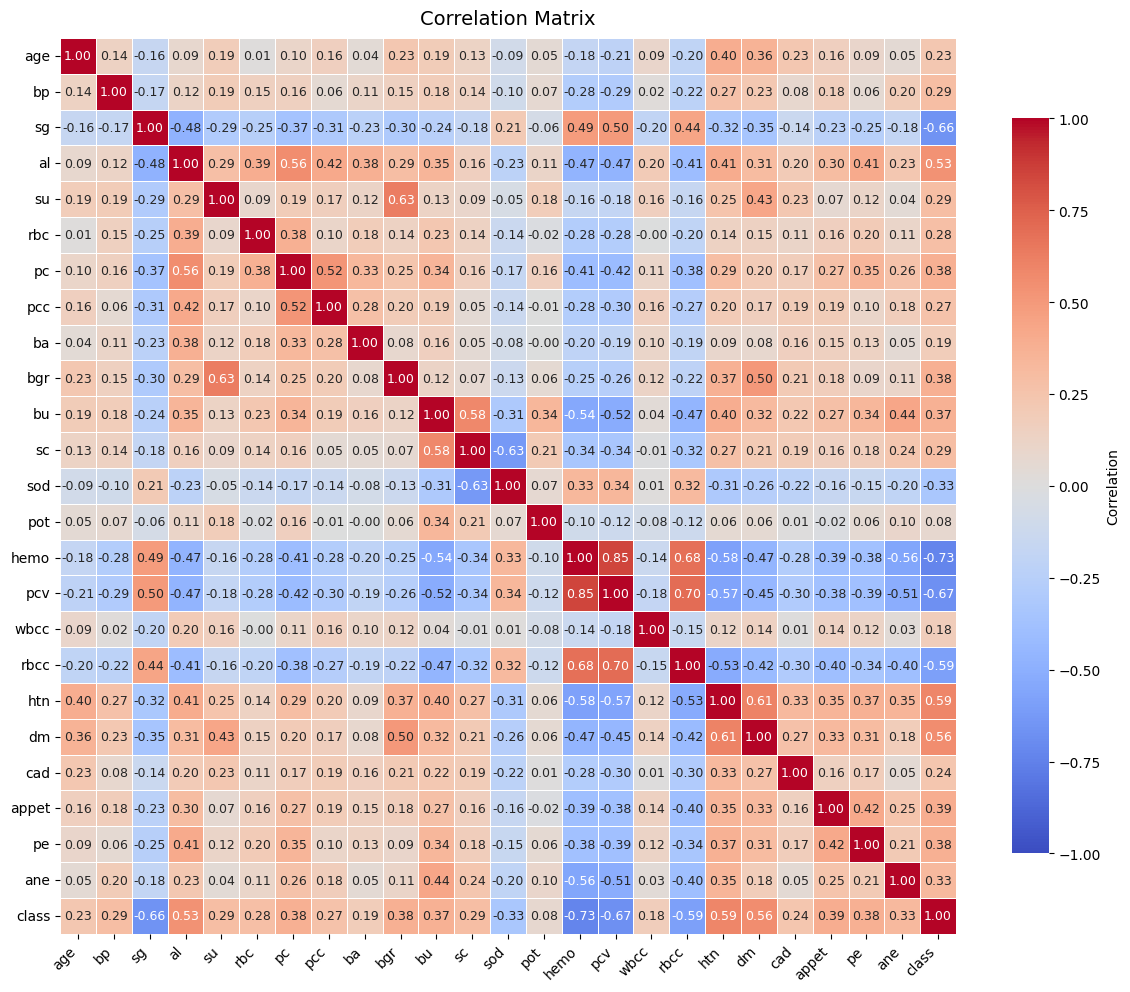

In [520]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8, "orientation": "vertical", "label": "Correlation"},
)

plt.title("Correlation Matrix", fontsize=14, pad=10)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### **Train-Test Splits**


In [521]:
X = df.drop(columns=["class"]).to_numpy()
y = df["class"].to_numpy()

X_cv, X_test, y_cv, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

### **Original and PCA Pipelines**


In [522]:
pipeline_org = Pipeline([("scaler", StandardScaler())])

pipeline_pca = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("rfe", RFE(RandomForestClassifier(random_state=SEED), n_features_to_select=12)),
        ("pca", PCA(n_components=8, svd_solver="full")),
    ]
)

In [ ]:
X_cv_org = pipeline_org.fit_transform(X_cv, y_cv)
X_test_org = pipeline_org.transform(X_test)

X_cv_pca = pipeline_pca.fit_transform(X_cv, y_cv)
X_test_pca = pipeline_pca.transform(X_test)

In [524]:
feature_names_out = pipeline_pca.named_steps["rfe"].get_feature_names_out(df.columns[:-1])

feature_names_out

array(['age', 'sg', 'al', 'bgr', 'bu', 'sc', 'sod', 'hemo', 'pcv', 'rbcc',
       'htn', 'dm'], dtype=object)

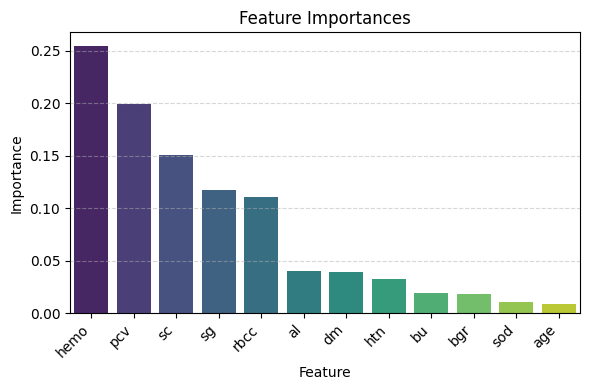

In [ ]:
feature_importances = pipeline_pca.named_steps["rfe"].estimator_.feature_importances_

plt.figure(figsize=(6, 4))

sns.barplot(
    pd.DataFrame({
        "feature": feature_names_out,
        "importance": feature_importances
    }).sort_values(by="importance", ascending=False),
    x="feature",
    y="importance",
    palette="viridis"
)

plt.title("Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

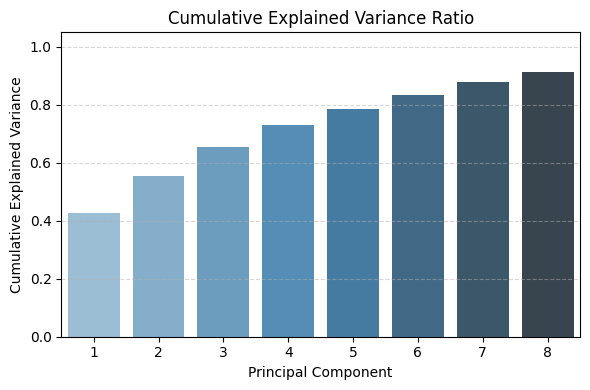

In [526]:
explained_var_ratio = pipeline_pca.named_steps["pca"].explained_variance_ratio_

plt.figure(figsize=(6, 4))

sns.barplot(
    x=np.arange(1, len(explained_var_ratio) + 1),
    y=explained_var_ratio.cumsum(),
    palette="Blues_d"
)

plt.title("Cumulative Explained Variance Ratio")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **Model Training**


### **Models**


In [527]:
standalone_models = {
    "AdaBoost": AdaBoostClassifier(random_state=SEED),
    "DecisionTree": DecisionTreeClassifier(random_state=SEED),
    "XGBoost": XGBClassifier(random_state=SEED),
    "CatBoost": CatBoostClassifier(random_state=SEED, verbose=0),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(random_state=SEED),
    "NaiveBayes": GaussianNB(),
    "GradientBoosting": GradientBoostingClassifier(random_state=SEED),
    "StochasticGB": GradientBoostingClassifier(random_state=SEED, subsample=0.1),
    "LGBM": LGBMClassifier(random_state=SEED, verbosity=-1),
    "ExtraTree": ExtraTreesClassifier(random_state=SEED),
    "SVM": SVC(kernel="linear", probability=True, random_state=SEED),
    "ANN": MLPClassifier(random_state=SEED),
}

models = {
    **standalone_models,
    "Hybrid": VotingClassifier(
        list(standalone_models.items()), voting="soft", n_jobs=-1
    ),
}

### **Evaluation Routine**


In [528]:
def get_scores(y_true, y_pred):
    score_args = {"zero_division": 0, "average": "weighted"}

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, **score_args),
        "recall": recall_score(y_true, y_pred, **score_args),
        "f1": f1_score(y_true, y_pred, **score_args),
    }


def add_scores(n, avg_scores, new_scores):
    for score_name, score_value in new_scores.items():
        a = 1 / (n + 1)
        curr_avg = avg_scores.get(score_name, 0)
        avg_scores[score_name] = (1 - a) * curr_avg + a * score_value


def run_evaluation(X_cv, X_test, y_cv, y_test, models):
    skf = StratifiedKFold(n_splits=10)
    models_results = []

    for model_name, model_instance in models.items():
        scores_cv = {}

        for n, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
            X_train, X_val = X_cv[train_idx], X_cv[val_idx]
            y_train, y_val = y_cv[train_idx], y_cv[val_idx]

            model_fold = clone(model_instance)

            model_fold.fit(X_train, y_train)

            y_pred = model_fold.predict(X_val)

            add_scores(n, scores_cv, get_scores(y_val, y_pred))

        model_final = clone(model_instance)

        model_final.fit(X_cv, y_cv)

        y_pred = model_final.predict(X_test)

        scores_test = get_scores(y_test, y_pred)

        models_results.append(
            {
                "model": model_name,
                **{
                    f"{score_name}_cv": score_value
                    for score_name, score_value in scores_cv.items()
                },
                **{
                    f"{score_name}_test": score_value
                    for score_name, score_value in scores_test.items()
                },
                "cm_test": confusion_matrix(y_test, y_pred),
            }
        )

    return pd.DataFrame(models_results)

### **Evaluation Results**


In [ ]:
df_results_org = run_evaluation(
    X_cv_org, X_test_org, y_cv, y_test, models
)

df_results_org

,model,accuracy_cv,precision_cv,recall_cv,f1_cv,accuracy_test,precision_test,recall_test,f1_test,cm_test
0,AdaBoost,0.978571,0.979744,0.978571,0.978639,1.000000,1.000000,1.000000,1.000000,"[[45, 0], [0, 75]]"
1,DecisionTree,0.960714,0.964521,0.960714,0.961099,0.958333,0.960069,0.958333,0.958580,"[[44, 1], [4, 71]]"
2,XGBoost,0.967857,0.970455,0.967857,0.968031,0.991667,0.991848,0.991667,0.991684,"[[45, 0], [1, 74]]"
3,CatBoost,0.971429,0.973773,0.971429,0.971645,1.000000,1.000000,1.000000,1.000000,"[[45, 0], [0, 75]]"
4,KNN,0.967857,0.972700,0.967857,0.968269,0.975000,0.976562,0.975000,0.975148,"[[45, 0], [3, 72]]"
5,RandomForest,0.989286,0.990007,0.989286,0.989252,0.991667,0.991848,0.991667,0.991684,"[[45, 0], [1, 74]]"
6,NaiveBayes,0.964286,0.969341,0.964286,0.964674,0.966667,0.969388,0.966667,0.966919,"[[45, 0], [4, 71]]"
7,GradientBoosting,0.975000,0.976544,0.975000,0.975139,0.991667,0.991848,0.991667,0.991684,"[[45, 0], [1, 74]]"
8,StochasticGB,0.950000,0.953371,0.950000,0.950241,0.966667,0.969388,0.966667,0.966919,"[[45, 0], [4, 71]]"
9,LGBM,0.992857,0.993479,0.992857,0.992915,0.991667,0.991848,0.991667,0.991684,"[[45, 0], [1, 74]]"


In [ ]:
df_results_pca = run_evaluation(
    X_cv_pca, X_test_pca, y_cv, y_test, models
)

df_results_pca

,model,accuracy_cv,precision_cv,recall_cv,f1_cv,accuracy_test,precision_test,recall_test,f1_test,cm_test
0,AdaBoost,0.982143,0.983340,0.982143,0.982075,0.966667,0.967502,0.966667,0.966804,"[[44, 1], [3, 72]]"
1,DecisionTree,0.982143,0.983476,0.982143,0.982155,0.966667,0.967502,0.966667,0.966804,"[[44, 1], [3, 72]]"
2,XGBoost,0.978571,0.979570,0.978571,0.978538,0.958333,0.960069,0.958333,0.958580,"[[44, 1], [4, 71]]"
3,CatBoost,0.985714,0.986860,0.985714,0.985772,0.983333,0.984043,0.983333,0.983402,"[[45, 0], [2, 73]]"
4,KNN,0.967857,0.972588,0.967857,0.968211,0.983333,0.984043,0.983333,0.983402,"[[45, 0], [2, 73]]"
5,RandomForest,0.985714,0.986750,0.985714,0.985703,1.000000,1.000000,1.000000,1.000000,"[[45, 0], [0, 75]]"
6,NaiveBayes,0.985714,0.986750,0.985714,0.985703,0.991667,0.991848,0.991667,0.991684,"[[45, 0], [1, 74]]"
7,GradientBoosting,0.978571,0.979706,0.978571,0.978617,0.966667,0.969388,0.966667,0.966919,"[[45, 0], [4, 71]]"
8,StochasticGB,0.982143,0.983090,0.982143,0.982234,0.975000,0.976562,0.975000,0.975148,"[[45, 0], [3, 72]]"
9,LGBM,0.985714,0.987088,0.985714,0.985613,0.966667,0.967502,0.966667,0.966804,"[[44, 1], [3, 72]]"


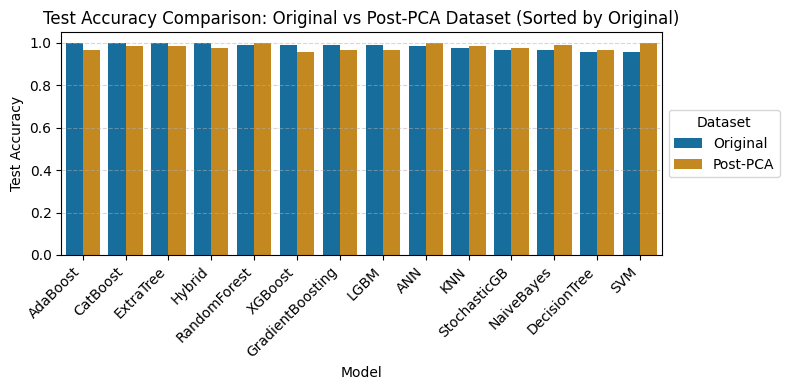

In [557]:
df_results_org['dataset'] = 'Original'
df_results_pca['dataset'] = 'Post-PCA'

df_results = pd.concat([df_results_org, df_results_pca])

plt.figure(figsize=(8, 4))

sns.barplot(
    df_results,
    x='model',
    y='accuracy_test',
    hue='dataset',
    palette='colorblind',
    order=df_results_org.sort_values(by='accuracy_test', ascending=False)['model']
)

plt.title('Test Accuracy Comparison: Original vs Post-PCA Dataset (Sorted by Original)')
plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()